# CSE 475 - Assignment 02
## Group Information

| Field | Details |
|---|---|
| **Group ID** | Group G |
| **Student 1 Name** | Aditya Debnath |
| **Student 1 ID** | 2022-2-60-124 |
| **Student 2 Name** | Umme Habiba |
| **Student 2 ID** | 2022-1-60-362 |
| **Student 3 Name** | Purnendu Bhowmik Shuvro |
| **Student 3 ID** | 2023-1-60-085 |
| **Student 4 Name** | Mujahida Nazmoon Naher |
| **Student 4 ID** | 2022-2-60-099 |
| **Notebook Type** | BYOL Notebook |
| **Backbone Used** | DeiT-Small/deit_small_patch16_224 (Best ViT — Assignment 01) |
| **Assignment 01 Best Acc** | 100.00% (DeiT-Small) |
| **Dataset Source Name** | Chilli Dataset 2024 |
| **Dataset Source Link** | https://data.mendeley.com/datasets/tf9dtfz9m6/2 |
| **Kaggle Dataset Path** | /kaggle/input/datasets/adityadebnathtirtha/chilli-dataset-2024/Chilli Dataset 2024 |
| **Submission Date** | 20 April 2026 |

---
## Table of Contents
1. [Global Configuration](#1)
2. [Setup and Imports](#2)
3. [Dataset EDA and Augmentation Visualisation](#3)
4. [BYOL: Model Definition](#4)
5. [BYOL: Pre-Training Loop](#5)
6. [BYOL: Training Curve](#6)
7. [Linear Probing with BYOL Backbone](#7)
8. [k-NN Evaluation with BYOL Backbone](#8)
9. [Ablation Study (Label-Fraction)](#9)
10. [Conclusion](#10)
11. [References](#11)


## 1. Global Configuration

In [1]:
!pip install timm --quiet
print('Libraries ready')

Libraries ready


In [2]:
import os, math, time, copy, json, warnings, re
warnings.filterwarnings('ignore')

BASE_DIR   = '/kaggle/input/datasets/adityadebnathtirtha/chilli-dataset-2024/Chilli Dataset 2024'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)
def safe_name(s): return re.sub(r'[^A-Za-z0-9._-]+', '_', str(s)).strip('_')

BACKBONE  = 'deit_small_patch16_224'
EMBED_DIM = 384        

IMG_SIZE = 224
SEED     = 42

SSL_EPOCHS   = 100     
SSL_BS       = 128      
SSL_LR       = 3e-4    
SSL_WD       = 1e-6    
EMA_BASE     = 0.996   

PROJ_HIDDEN = 4096
PROJ_DIM    = 256

LP_EPOCHS   = 50
LP_LR       = 0.01 
LP_MOMENTUM = 0.9
LP_BS       = 128

KNN_KS = [1, 5, 10, 20, 50, 100, 200]

MU  = [0.485, 0.456, 0.406]
SIG = [0.229, 0.224, 0.225]

WALL_LIMIT = 8.5 * 3600
_T0        = time.time()

print('Configuration loaded')
print(f'  Backbone  : {BACKBONE}  (embed_dim={EMBED_DIM})')
print(f'  SSL       : {SSL_EPOCHS} epochs | bs={SSL_BS} | lr={SSL_LR}')
print(f'  LP        : {LP_EPOCHS} epochs | SGD lr={LP_LR}')
print(f'  k-NN k    : {KNN_KS}')

Configuration loaded
  Backbone  : deit_small_patch16_224  (embed_dim=384)
  SSL       : 100 epochs | bs=128 | lr=0.0003
  LP        : 50 epochs | SGD lr=0.01
  k-NN k    : [1, 5, 10, 20, 50, 100, 200]


## 2. Setup and Imports

In [3]:
import random, copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from PIL import Image

import timm
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                              precision_recall_fscore_support)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
        torch.backends.cudnn.benchmark     = True
        torch.backends.cudnn.deterministic = False

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP    = DEVICE.type == 'cuda'
N_GPU  = torch.cuda.device_count()

print(f'PyTorch {torch.__version__}  |  timm {timm.__version__}')
print(f'Device : {DEVICE}  |  GPUs: {N_GPU}  |  AMP: {AMP}')
if DEVICE.type == 'cuda':
    for i in range(N_GPU):
        p = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {p.name}  {p.total_memory/1e9:.1f} GB')

PyTorch 2.10.0+cu128  |  timm 1.0.25
Device : cuda  |  GPUs: 2  |  AMP: True
  GPU 0: Tesla T4  15.6 GB
  GPU 1: Tesla T4  15.6 GB


## 3. Dataset EDA and Augmentation Visualisation

### Dataset Acknowledgement
> **Dataset**: Chilli Dataset 2024 | https://data.mendeley.com/datasets/tf9dtfz9m6/2  
> Used strictly for educational purposes within CSE 475.

### Split Rationale (80 / 10 / 10)
| Split | Purpose | Labels? | Fraction |
|---|---|---|---|
| 80% | SSL unlabelled pre-training pool | No — discarded | 80% |
| 10% | Linear probe & k-NN training set | Yes | 10% |
| 10% | Held-out test set | Yes (eval only) | 10% |

Stratified splitting preserves the original class distribution in every split. A large unlabelled pool maximises the self-supervised learning signal.


In [4]:
EXTS = {'.jpg','.jpeg','.png','.bmp','.webp','.tiff'}

def discover(root):
    root = Path(root); records = []
    subdirs = [d for d in root.iterdir() if d.is_dir()]
    split_kw = {'train','test','val','valid','Train','Test','Val'}
    if {d.name for d in subdirs}.issubset(split_kw):
        for sp in subdirs:
            for cls in sp.iterdir():
                if cls.is_dir():
                    for f in cls.iterdir():
                        if f.suffix.lower() in EXTS:
                            records.append((str(f), cls.name))
    else:
        for cls in subdirs:
            for f in cls.iterdir():
                if f.suffix.lower() in EXTS:
                    records.append((str(f), cls.name))
    return records

all_records = discover(BASE_DIR)
CLASS_NAMES = sorted({r[1] for r in all_records})
NUM_CLASSES = len(CLASS_NAMES)
C2I         = {c:i for i,c in enumerate(CLASS_NAMES)}
cnt         = Counter(r[1] for r in all_records)
N_TOTAL     = len(all_records)
short       = [c[:18] for c in CLASS_NAMES]

print(f'Total images : {N_TOTAL}')
print(f'Classes ({NUM_CLASSES}):')
for c in CLASS_NAMES:
    print(f'  {c:<40}  {cnt[c]:>5} images  ({cnt[c]/N_TOTAL:.1%})')

Total images : 10987
Classes (5):
  cercospora                                 2219 images  (20.2%)
  healthy                                    2198 images  (20.0%)
  mites_and_trips                            2507 images  (22.8%)
  nutritional                                2032 images  (18.5%)
  powdery mildew                             2031 images  (18.5%)


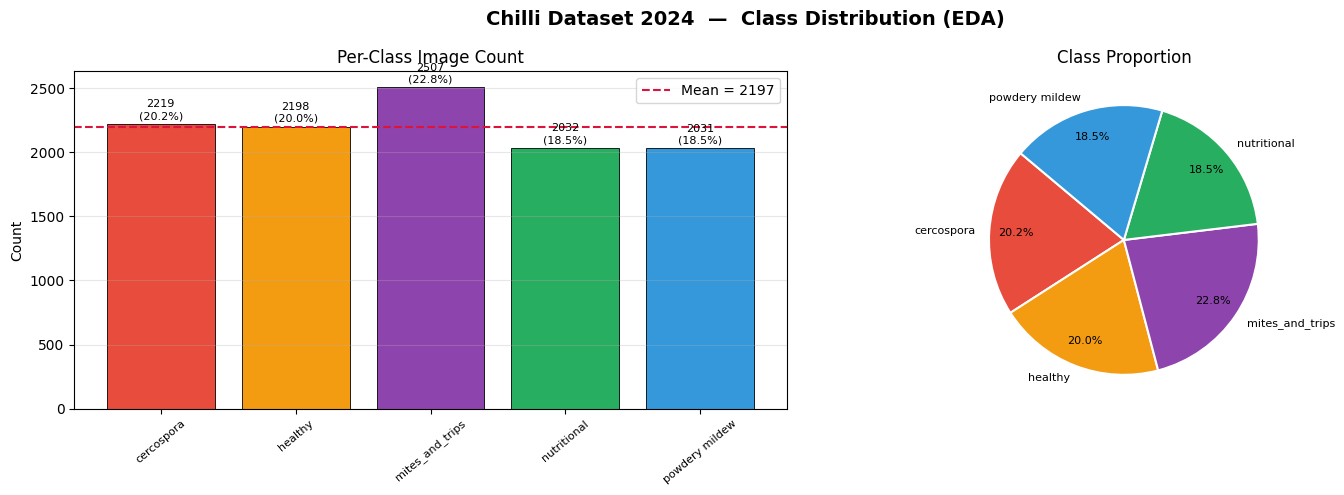

Imbalance ratio (max/min): 1.23
Saved: eda_class_distribution.png


In [5]:
COLORS = ['#E74C3C','#F39C12','#8E44AD','#27AE60','#3498DB',
          '#1ABC9C','#E67E22','#2ECC71','#9B59B6','#34495E']
c_colors = [COLORS[i % len(COLORS)] for i in range(NUM_CLASSES)]

labels = CLASS_NAMES
counts = [cnt[c] for c in CLASS_NAMES]
avg    = N_TOTAL / NUM_CLASSES

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Chilli Dataset 2024  —  Class Distribution (EDA)', fontsize=14, fontweight='bold')

# Bar
bars = axes[0].bar(short, counts, color=c_colors, edgecolor='black', linewidth=0.6)
axes[0].axhline(avg, color='crimson', ls='--', lw=1.5, label=f'Mean = {avg:.0f}')
axes[0].set_title('Per-Class Image Count'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=40, labelsize=8); axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for b, cv in zip(bars, counts):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+max(counts)*0.01,
                 f'{cv}\n({cv/N_TOTAL:.1%})', ha='center', va='bottom', fontsize=8)

axes[1].pie(counts, labels=short, autopct='%1.1f%%', startangle=140,
            colors=c_colors, wedgeprops={'edgecolor':'white','linewidth':1.5},
            pctdistance=0.80, textprops={'fontsize':8})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio (max/min): {max(counts)/min(counts):.2f}')
print('Saved: eda_class_distribution.png')

In [6]:
all_paths = [r[0] for r in all_records]
all_lbls  = [C2I[r[1]] for r in all_records]

paths_ssl, paths_rem, lbls_ssl, lbls_rem = train_test_split(
    all_paths, all_lbls, test_size=0.20, stratify=all_lbls, random_state=SEED)
paths_probe, paths_test, lbls_probe, lbls_test = train_test_split(
    paths_rem, lbls_rem, test_size=0.50, stratify=lbls_rem, random_state=SEED)

print('=' * 56)
print(f'  {"Split":<30} {"N":>6}  {"Fraction":>9}')
print('=' * 56)
print(f'  {"SSL pool (unlabelled)":<30} {len(paths_ssl):>6}  {len(paths_ssl)/N_TOTAL:.1%}')
print(f'  {"Probe / k-NN train":<30} {len(paths_probe):>6}  {len(paths_probe)/N_TOTAL:.1%}')
print(f'  {"Held-out test":<30} {len(paths_test):>6}  {len(paths_test)/N_TOTAL:.1%}')
print(f'  {"Total":<30} {N_TOTAL:>6}')
print('=' * 56)

print('\nPer-class in probe split:')
probe_cnt = Counter(lbls_probe)
for i, c in enumerate(CLASS_NAMES):
    print(f'  {c:<40} {probe_cnt[i]:>4}')

n_s = min(300, len(paths_ssl))
samp = random.sample(paths_ssl, n_s)
pix = np.stack([np.array(Image.open(p).convert('RGB').resize((64,64)))/255. for p in samp])
ch_mean, ch_std = pix.mean(axis=(0,1,2)), pix.std(axis=(0,1,2))
print(f'\nPer-channel stats (N={n_s} sampled, 64x64):')
print(f'  Mean: R={ch_mean[0]:.4f}  G={ch_mean[1]:.4f}  B={ch_mean[2]:.4f}')
print(f'  Std : R={ch_std[0]:.4f}  G={ch_std[1]:.4f}  B={ch_std[2]:.4f}')

  Split                               N   Fraction
  SSL pool (unlabelled)            8789  80.0%
  Probe / k-NN train               1099  10.0%
  Held-out test                    1099  10.0%
  Total                           10987

Per-class in probe split:
  cercospora                                222
  healthy                                   220
  mites_and_trips                           251
  nutritional                               203
  powdery mildew                            203

Per-channel stats (N=300 sampled, 64x64):
  Mean: R=0.5427  G=0.5535  B=0.3999
  Std : R=0.2010  G=0.1903  B=0.1953


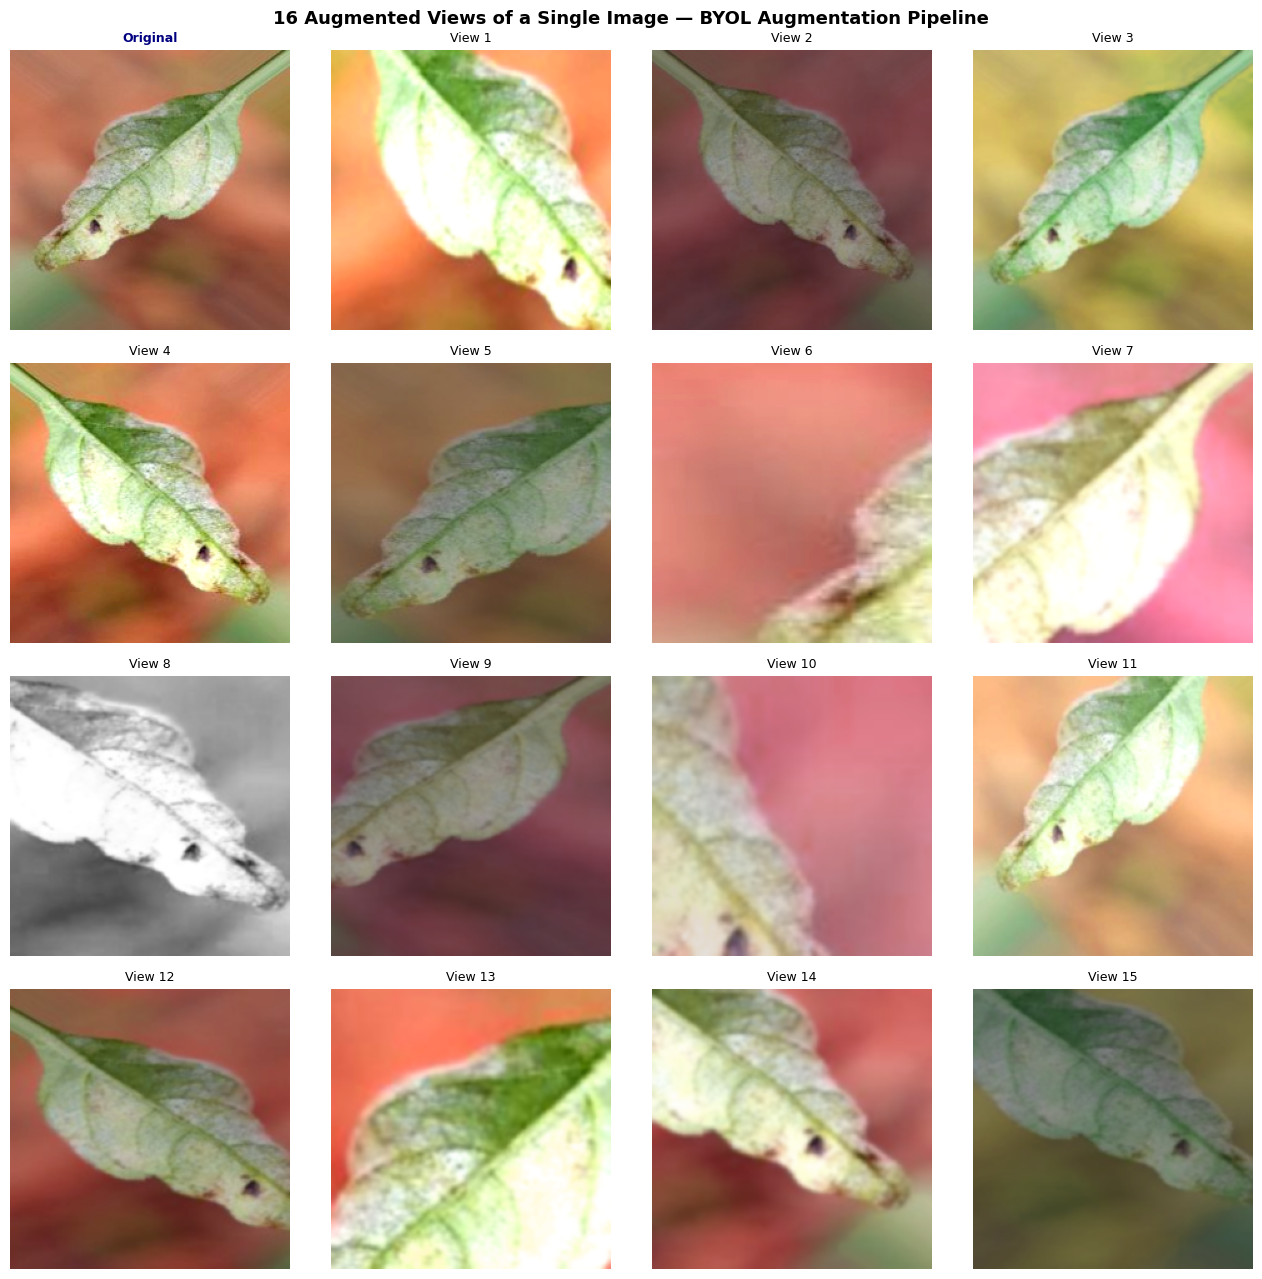

Saved: eda_augmentation_grid.png
BYOL augmentation steps:
  1. RandomResizedCrop(224, scale=0.08-1.0)   primary spatial diversity
  2. RandomHorizontalFlip(p=0.5)              mirror invariance
  3. ColorJitter(b=0.4,c=0.4,s=0.2,h=0.1)    colour/contrast invariance
  4. RandomGrayscale(p=0.2)                   colour channel dropout
  5. GaussianBlur(kernel=23, sigma=0.1-2.0)   sharpness invariance


In [7]:
byol_aug = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.08, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.Normalize(MU, SIG),
])

eval_tf = T.Compose([
    T.Resize(int(IMG_SIZE * 1.143)),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(MU, SIG),
])

def unnorm(t):
    m = torch.tensor(MU).view(3,1,1)
    s = torch.tensor(SIG).view(3,1,1)
    return torch.clamp(t*s+m, 0, 1).permute(1,2,0).numpy()

sample_img = Image.open(paths_ssl[0]).convert('RGB')

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
fig.suptitle('16 Augmented Views of a Single Image — BYOL Augmentation Pipeline',
             fontsize=13, fontweight='bold')
for idx, ax in enumerate(axes.flat):
    if idx == 0:
        ax.imshow(sample_img.resize((IMG_SIZE, IMG_SIZE)))
        ax.set_title('Original', fontsize=9, color='navy', fontweight='bold')
    else:
        ax.imshow(unnorm(byol_aug(sample_img)))
        ax.set_title(f'View {idx}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_augmentation_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_augmentation_grid.png')
print('BYOL augmentation steps:')
print('  1. RandomResizedCrop(224, scale=0.08-1.0)   primary spatial diversity')
print('  2. RandomHorizontalFlip(p=0.5)              mirror invariance')
print('  3. ColorJitter(b=0.4,c=0.4,s=0.2,h=0.1)    colour/contrast invariance')
print('  4. RandomGrayscale(p=0.2)                   colour channel dropout')
print('  5. GaussianBlur(kernel=23, sigma=0.1-2.0)   sharpness invariance')

## 4. BYOL: Model Definition

| Component | Specification |
|---|---|
| Backbone | DeiT-Small, embed_dim=384 |
| Projector | Linear(384,4096)+BN+ReLU -> Linear(4096,4096)+BN+ReLU -> Linear(4096,256)+BN |
| Predictor | Linear(256,4096)+BN+ReLU -> Linear(4096,256) |
| Loss | Symmetric negative cosine similarity: 2 - 2*cosine_sim |
| EMA | tau: 0.996->1.0 cosine schedule over 100 epochs |
| Optimiser | AdamW (lr=3e-4, wd=1e-6), AMP mixed precision |


In [8]:
class Projector(nn.Module):
    def __init__(self, in_dim, hidden=PROJ_HIDDEN, out_dim=PROJ_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden, bias=False),
            nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden, bias=False),
            nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim, bias=False),
            nn.BatchNorm1d(out_dim, affine=False),  
        )
    def forward(self, x): return self.net(x)

class Predictor(nn.Module):
    def __init__(self, dim=PROJ_DIM, hidden=PROJ_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden, bias=False),
            nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, dim),
        )
    def forward(self, x): return self.net(x)

print('Projector(3-layer BN) and Predictor(2-layer BN) defined.')

Projector(3-layer BN) and Predictor(2-layer BN) defined.


In [9]:
class OnlineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone  = timm.create_model(BACKBONE, pretrained=True, num_classes=0)
        feat            = self.backbone.num_features  
        self.projector  = Projector(feat)
        self.predictor  = Predictor()
        print(f'  OnlineNet  backbone features: {feat}')
    def forward(self, x):
        f = self.backbone(x)
        z = self.projector(f)
        q = self.predictor(z)
        return q, f

class TargetNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone  = timm.create_model(BACKBONE, pretrained=True, num_classes=0)
        feat            = self.backbone.num_features
        self.projector  = Projector(feat)
        print(f'  TargetNet  backbone features: {feat}')
    def forward(self, x):
        return self.projector(self.backbone(x))

print('Building BYOL networks (DeiT-Small)...')
online = OnlineNet()
target = TargetNet()

src = {k: v.clone() for k,v in online.state_dict().items() if k in target.state_dict()}
target.load_state_dict(src)
for p in target.parameters(): p.requires_grad_(False)

if N_GPU > 1:
    online = nn.DataParallel(online)
    target = nn.DataParallel(target)
    print(f'  DataParallel on {N_GPU} GPUs')

online = online.to(DEVICE)
target = target.to(DEVICE)

total_p   = sum(p.numel() for p in online.parameters())
trainable = sum(p.numel() for p in online.parameters() if p.requires_grad)
print(f'  Total params    : {total_p:,}')
print(f'  Trainable       : {trainable:,}')
print('  Target gradients: OFF  (EMA only)')

Building BYOL networks (DeiT-Small)...


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

  OnlineNet  backbone features: 384


  TargetNet  backbone features: 384
  DataParallel on 2 GPUs
  Total params    : 43,186,304
  Trainable       : 43,186,304
  Target gradients: OFF  (EMA only)


In [10]:
def byol_loss(q, z):
    q = F.normalize(q, dim=-1)
    z = F.normalize(z.detach(), dim=-1)   
    return 2. - 2. * (q * z).sum(dim=-1).mean()

def tau_sched(epoch):
    return 1. - (1. - EMA_BASE) * (math.cos(math.pi * epoch / SSL_EPOCHS) + 1.) / 2.

@torch.no_grad()
def ema_update(src_net, tgt_net, tau):
    src = src_net.module if hasattr(src_net, 'module') else src_net
    tgt = tgt_net.module if hasattr(tgt_net, 'module') else tgt_net
    for ps, pt in zip(src.parameters(), tgt.parameters()):
        pt.data.mul_(tau).add_((1. - tau) * ps.data)

_params = (online.module if hasattr(online,'module') else online).parameters()
optimizer = optim.AdamW(_params, lr=SSL_LR, weight_decay=SSL_WD)
scaler    = GradScaler(enabled=AMP)

print(f'AdamW  lr={SSL_LR}  wd={SSL_WD}')
print(f'EMA schedule: tau {EMA_BASE} -> 1.0 over {SSL_EPOCHS} epochs')

AdamW  lr=0.0003  wd=1e-06
EMA schedule: tau 0.996 -> 1.0 over 100 epochs


## 5. BYOL: Pre-Training Loop

In [11]:
class BYOLDataset(Dataset):
    def __init__(self, paths, aug):
        self.paths = paths; self.aug = aug
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return self.aug(img), self.aug(img)  

ssl_ds     = BYOLDataset(paths_ssl, byol_aug)
ssl_loader = DataLoader(ssl_ds, batch_size=SSL_BS, shuffle=True,
                        num_workers=8, pin_memory=True, drop_last=True)

_b = next(iter(ssl_loader))
assert len(_b) == 2, f'Label leak detected! Got {len(_b)} items.'
print(f'SSL loader  : {len(ssl_ds)} images  |  batch {SSL_BS}')
print(f'Batch shape : {_b[0].shape}')
print('Label removal CONFIRMED — batch yields (view1, view2) only.')

SSL loader  : 8789 images  |  batch 128
Batch shape : torch.Size([128, 3, 224, 224])
Label removal CONFIRMED — batch yields (view1, view2) only.


In [12]:
ssl_losses  = []   
tau_history = []   

print(f'Starting BYOL Pre-Training — {SSL_EPOCHS} epochs')
print(f'Backbone  : DeiT-Small  |  AMP: {AMP}  |  GPUs: {N_GPU}')
print('=' * 68)

for epoch in range(1, SSL_EPOCHS + 1):
    if time.time() - _T0 > WALL_LIMIT:
        print(f'Wall-clock limit at epoch {epoch}. Stopping early.'); break

    tau = tau_sched(epoch - 1)
    online.train(); target.eval()
    epoch_loss = 0.

    pbar = tqdm(ssl_loader, desc=f'[SSL {epoch:>3}/{SSL_EPOCHS}]',
                leave=False, ncols=90, unit='batch')
    for v1, v2 in pbar:
        v1, v2 = v1.to(DEVICE), v2.to(DEVICE)
        with autocast(enabled=AMP):
            q1, _ = online(v1)
            q2, _ = online(v2)
            with torch.no_grad():
                z1 = target(v1)
                z2 = target(v2)
            loss = (byol_loss(q1, z2) + byol_loss(q2, z1)) / 2.

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(
            (online.module if hasattr(online,'module') else online).parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        ema_update(online, target, tau)

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}', tau=f'{tau:.4f}')

    avg = epoch_loss / len(ssl_loader)
    ssl_losses.append(avg)
    tau_history.append(tau)

    if epoch % 10 == 0 or epoch == 1 or epoch == SSL_EPOCHS:
        elapsed = (time.time() - _T0) / 60
        print(f'Epoch [{epoch:>3}/{SSL_EPOCHS}]  Loss: {avg:.4f}  tau: {tau:.5f}  '
              f'Elapsed: {elapsed:.1f} min')

_bb = (online.module if hasattr(online,'module') else online).backbone
torch.save(_bb.state_dict(), f'{OUTPUT_DIR}/byol_backbone.pth')
print(f'\nPre-training complete.')
print(f'  Epochs   : {len(ssl_losses)}')
print(f'  Loss[0]  : {ssl_losses[0]:.4f}')
print(f'  Loss[-1] : {ssl_losses[-1]:.4f}')
print(f'  Saved    : byol_backbone.pth')

Starting BYOL Pre-Training — 100 epochs
Backbone  : DeiT-Small  |  AMP: True  |  GPUs: 2


Epoch [  1/100]  Loss: 0.2730  tau: 0.99600  Elapsed: 9.3 min


Epoch [ 10/100]  Loss: 0.1235  tau: 0.99608  Elapsed: 74.6 min


Epoch [ 20/100]  Loss: 0.0500  tau: 0.99635  Elapsed: 155.1 min


Epoch [ 30/100]  Loss: 0.0757  tau: 0.99677  Elapsed: 238.4 min


Epoch [ 40/100]  Loss: 0.2215  tau: 0.99732  Elapsed: 322.1 min


Epoch [ 50/100]  Loss: 0.2410  tau: 0.99794  Elapsed: 405.7 min


Epoch [ 60/100]  Loss: 0.2398  tau: 0.99856  Elapsed: 489.6 min


Wall-clock limit at epoch 64. Stopping early.

Pre-training complete.
  Epochs   : 63
  Loss[0]  : 0.2730
  Loss[-1] : 0.2206
  Saved    : byol_backbone.pth


## 6. BYOL: Training Curve

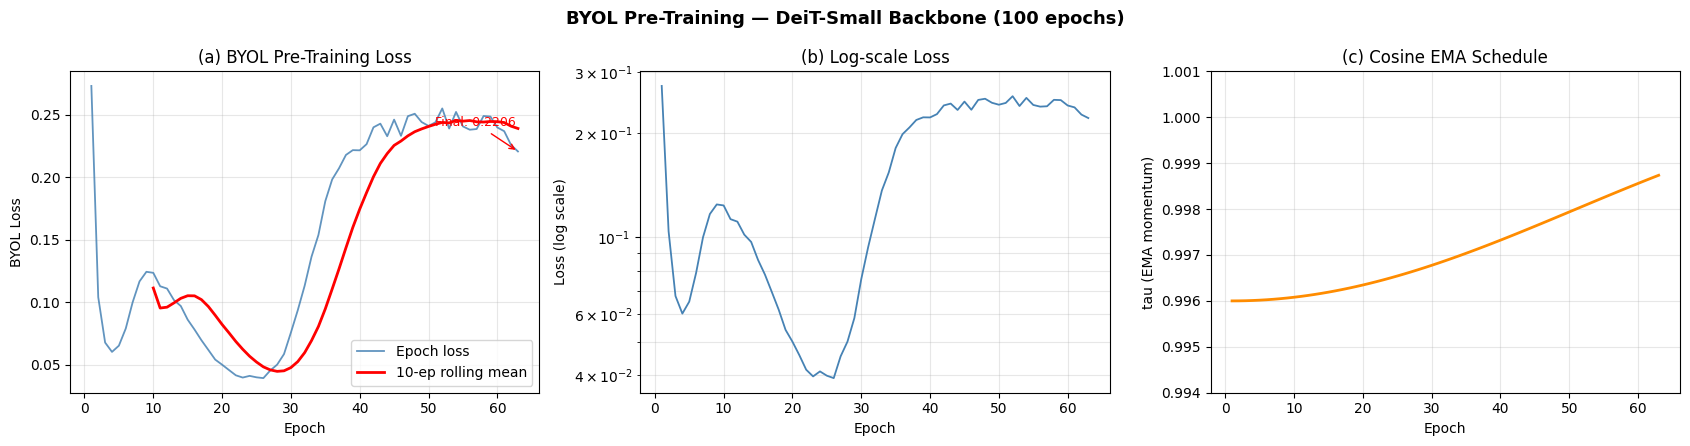

Saved: byol_training_curves.png
Convergence: 0.2730 -> 0.2206  (19.2% decrease)
Min loss: 0.0392 at epoch 26


In [13]:
epochs_ran = len(ssl_losses)
xs = list(range(1, epochs_ran + 1))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
fig.suptitle('BYOL Pre-Training — DeiT-Small Backbone (100 epochs)',
             fontsize=13, fontweight='bold')

axes[0].plot(xs, ssl_losses, color='steelblue', lw=1.3, alpha=0.85, label='Epoch loss')
if epochs_ran >= 10:
    rm = np.convolve(ssl_losses, np.ones(10)/10, mode='valid')
    axes[0].plot(range(10, epochs_ran+1), rm, 'r-', lw=2.0, label='10-ep rolling mean')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BYOL Loss')
axes[0].set_title('(a) BYOL Pre-Training Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].annotate(f'Final: {ssl_losses[-1]:.4f}',
                 xy=(epochs_ran, ssl_losses[-1]), xytext=(-60, 18),
                 textcoords='offset points', fontsize=9, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))

axes[1].semilogy(xs, ssl_losses, color='steelblue', lw=1.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('(b) Log-scale Loss'); axes[1].grid(alpha=0.3, which='both')

axes[2].plot(xs, tau_history, color='darkorange', lw=2.0)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('tau (EMA momentum)')
axes[2].set_title('(c) Cosine EMA Schedule'); axes[2].grid(alpha=0.3)
axes[2].set_ylim(EMA_BASE - 0.002, 1.001)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/byol_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: byol_training_curves.png')
print(f'Convergence: {ssl_losses[0]:.4f} -> {ssl_losses[-1]:.4f}  '
      f'({(ssl_losses[0]-ssl_losses[-1])/ssl_losses[0]*100:.1f}% decrease)')
print(f'Min loss: {min(ssl_losses):.4f} at epoch {ssl_losses.index(min(ssl_losses))+1}')

## 7. Linear Probing with BYOL Backbone

- Backbone completely **frozen** — zero gradient through it.
- Single `nn.Linear(384, num_classes)` trained on the **10% labelled probe set**.
- SGD (lr=0.01, momentum=0.9), cosine LR, 50 epochs.
- Metrics: Top-1 accuracy, Top-5 (if classes ≥ 10), confusion matrix, per-class F1.


In [14]:
class LabelledDs(Dataset):
    def __init__(self, paths, labels, tf):
        self.paths=paths; self.labels=labels; self.tf=tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert('RGB')), self.labels[i]

probe_ds = LabelledDs(paths_probe, lbls_probe, eval_tf)
test_ds  = LabelledDs(paths_test,  lbls_test,  eval_tf)
probe_loader = DataLoader(probe_ds, batch_size=LP_BS, shuffle=True,
                          num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=LP_BS, shuffle=False,
                          num_workers=8, pin_memory=True)
print(f'Probe (labelled train): {len(probe_ds)}')
print(f'Test  (held-out)      : {len(test_ds)}')

Probe (labelled train): 1099
Test  (held-out)      : 1099


In [15]:
byol_backbone = (online.module if hasattr(online,'module') else online).backbone
byol_backbone.eval()
for p in byol_backbone.parameters(): p.requires_grad_(False)

lp_head    = nn.Linear(EMBED_DIM, NUM_CLASSES).to(DEVICE)
lp_optim   = optim.SGD(lp_head.parameters(), lr=LP_LR, momentum=LP_MOMENTUM)
lp_sched   = optim.lr_scheduler.CosineAnnealingLR(lp_optim, T_max=LP_EPOCHS)
criterion  = nn.CrossEntropyLoss()

lp_train_loss = []; lp_test_acc = []
best_acc = 0.; best_state = None

print(f'Linear probe: frozen DeiT-Small + nn.Linear({EMBED_DIM},{NUM_CLASSES})')
print(f'SGD lr={LP_LR}  momentum={LP_MOMENTUM}  {LP_EPOCHS} epochs  cosine LR')
print('=' * 68)

for epoch in range(1, LP_EPOCHS + 1):
    lp_head.train()
    ep_loss = 0.
    for imgs, lbls in probe_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        with torch.no_grad():
            feats = byol_backbone(imgs)
        loss = criterion(lp_head(feats), lbls)
        lp_optim.zero_grad(); loss.backward(); lp_optim.step()
        ep_loss += loss.item()
    lp_sched.step()
    lp_train_loss.append(ep_loss / len(probe_loader))

    lp_head.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            correct += (lp_head(byol_backbone(imgs)).argmax(1)==lbls).sum().item()
            total   += lbls.size(0)
    acc = correct/total*100
    lp_test_acc.append(acc)
    if acc > best_acc: best_acc=acc; best_state=copy.deepcopy(lp_head.state_dict())
    if epoch % 10 == 0 or epoch == 1:
        print(f'LP [{epoch:>2}/{LP_EPOCHS}]  Loss:{lp_train_loss[-1]:.4f}  '
              f'Test acc:{acc:.2f}%')

lp_head.load_state_dict(best_state)
print(f'\nLinear probe done.  Best test accuracy: {best_acc:.2f}%')

Linear probe: frozen DeiT-Small + nn.Linear(384,5)
SGD lr=0.01  momentum=0.9  50 epochs  cosine LR
LP [ 1/50]  Loss:1.5406  Test acc:52.78%
LP [10/50]  Loss:0.5392  Test acc:77.34%
LP [20/50]  Loss:0.4644  Test acc:79.89%
LP [30/50]  Loss:0.4300  Test acc:80.89%
LP [40/50]  Loss:0.4191  Test acc:80.80%
LP [50/50]  Loss:0.4182  Test acc:80.16%

Linear probe done.  Best test accuracy: 80.89%


In [16]:
lp_head.eval(); byol_backbone.eval()
all_preds, all_true, all_probs = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs  = imgs.to(DEVICE)
        logits = lp_head(byol_backbone(imgs))
        all_probs.append(torch.softmax(logits,1).cpu().numpy())
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(lbls.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
all_probs = np.vstack(all_probs)

byol_top1     = (all_preds == all_true).mean() * 100
f1_cls        = f1_score(all_true, all_preds, average=None, labels=list(range(NUM_CLASSES)))
byol_macro_f1 = f1_score(all_true, all_preds, average='macro')
prec, rec, _, _ = precision_recall_fscore_support(all_true, all_preds, average='macro')

if NUM_CLASSES >= 10:
    top5 = sum(all_true[i] in np.argsort(all_probs[i])[-5:] for i in range(len(all_true)))
    byol_top5 = top5/len(all_true)*100
else:
    byol_top5 = None

print('=' * 60)
print('  BYOL Linear Probe Results  —  DeiT-Small')
print('=' * 60)
print(f'  Top-1 Accuracy  : {byol_top1:.2f}%')
if byol_top5: print(f'  Top-5 Accuracy  : {byol_top5:.2f}%')
print(f'  Macro Precision : {prec*100:.2f}%')
print(f'  Macro Recall    : {rec*100:.2f}%')
print(f'  Macro F1        : {byol_macro_f1:.4f}')
print('=' * 60)
print('\nPer-class F1 scores:')
for i, c in enumerate(CLASS_NAMES):
    bar = chr(9608) * int(f1_cls[i] * 20)
    print(f'  {c:<40} {f1_cls[i]:.4f}  {bar}')
print('\nFull Classification Report:')
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, digits=4))

  BYOL Linear Probe Results  —  DeiT-Small
  Top-1 Accuracy  : 80.89%
  Macro Precision : 80.99%
  Macro Recall    : 81.19%
  Macro F1        : 0.8098

Per-class F1 scores:
  cercospora                               0.7411  ██████████████
  healthy                                  0.7588  ███████████████
  mites_and_trips                          0.8047  ████████████████
  nutritional                              0.7710  ███████████████
  powdery mildew                           0.9735  ███████████████████

Full Classification Report:
                 precision    recall  f1-score   support

     cercospora     0.7839    0.7027    0.7411       222
        healthy     0.7826    0.7364    0.7588       220
mites_and_trips     0.7969    0.8127    0.8047       251
    nutritional     0.7333    0.8128    0.7710       203
 powdery mildew     0.9528    0.9951    0.9735       203

       accuracy                         0.8089      1099
      macro avg     0.8099    0.8119    0.8098      1099
 

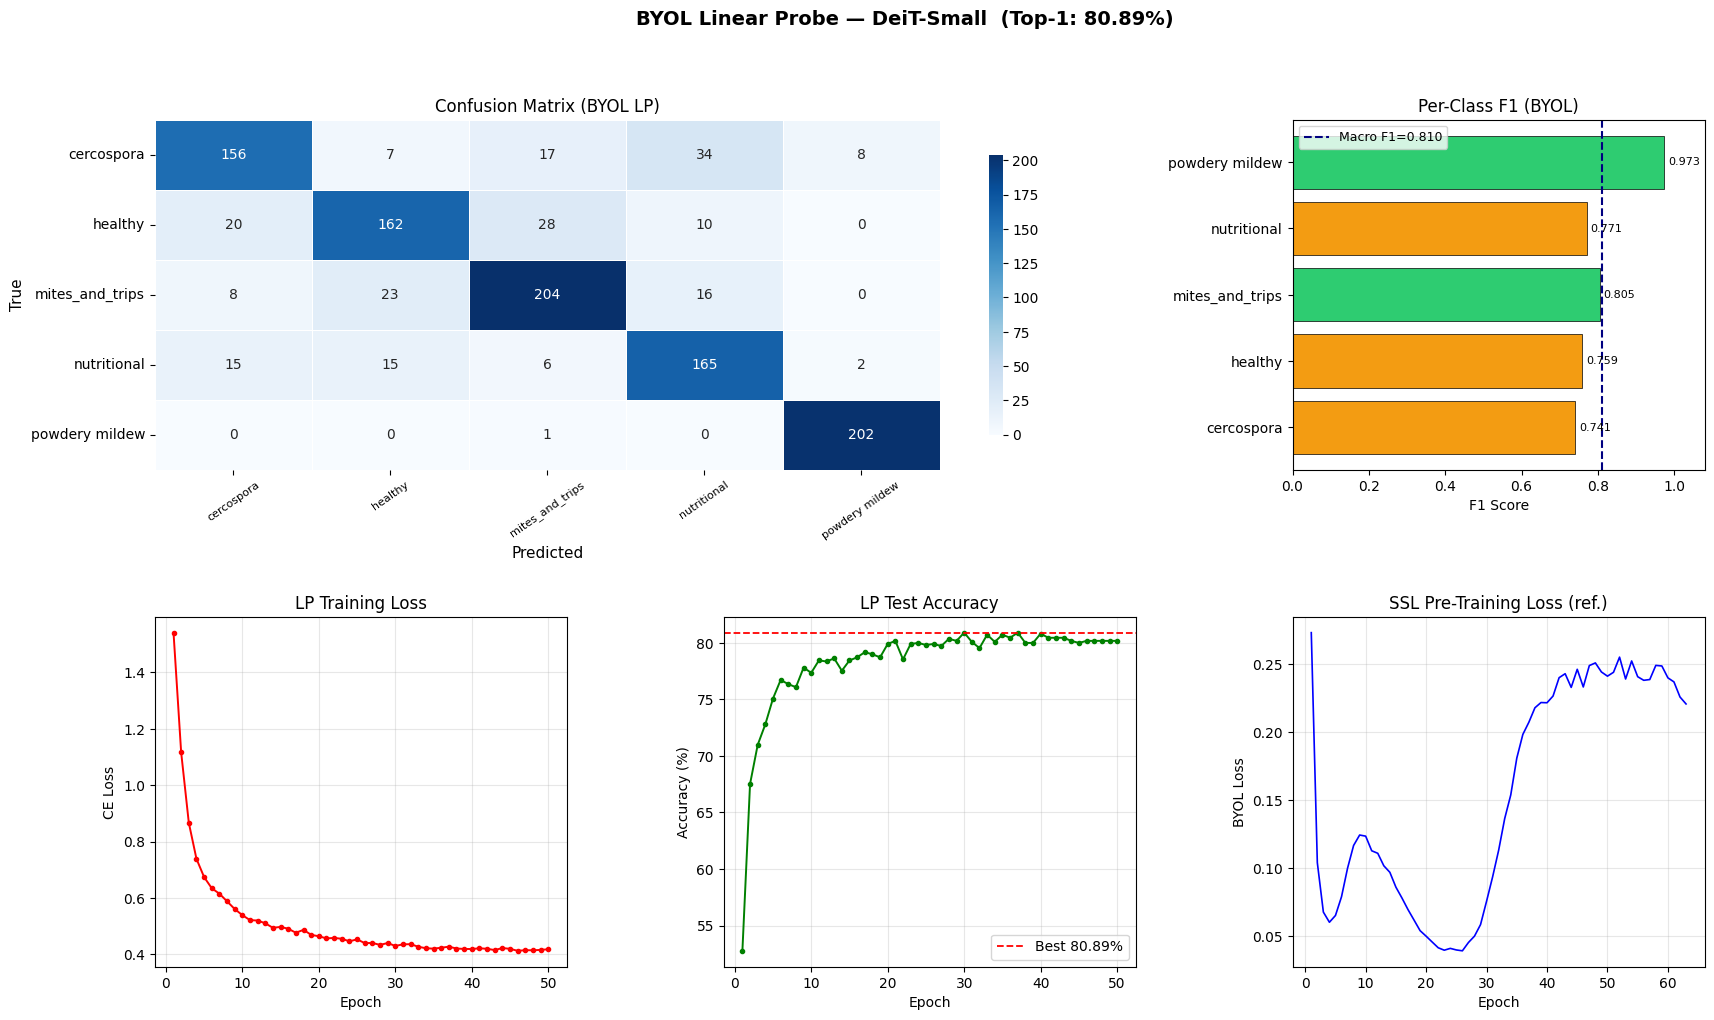

Saved: byol_lp_full_results.png


In [17]:
fig = plt.figure(figsize=(20, 11))
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.38)
fig.suptitle(f'BYOL Linear Probe — DeiT-Small  (Top-1: {byol_top1:.2f}%)',
             fontsize=14, fontweight='bold')

ax_cm = fig.add_subplot(gs[0, :2])
cm    = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
            xticklabels=short, yticklabels=short,
            linewidths=0.4, cbar_kws={'shrink':0.8})
ax_cm.set_xlabel('Predicted', fontsize=11); ax_cm.set_ylabel('True', fontsize=11)
ax_cm.set_title('Confusion Matrix (BYOL LP)')
ax_cm.tick_params(axis='x', rotation=35, labelsize=8)

ax_f1 = fig.add_subplot(gs[0, 2])
bcolors = ['#2ecc71' if f>=0.8 else ('#f39c12' if f>=0.5 else '#e74c3c') for f in f1_cls]
ax_f1.barh(short, f1_cls, color=bcolors, edgecolor='black', lw=0.5)
ax_f1.axvline(byol_macro_f1, color='navy', ls='--', lw=1.5,
              label=f'Macro F1={byol_macro_f1:.3f}')
ax_f1.set_xlabel('F1 Score'); ax_f1.set_title('Per-Class F1 (BYOL)')
ax_f1.set_xlim(0, 1.08); ax_f1.legend(fontsize=9)
for i, f in enumerate(f1_cls):
    ax_f1.text(f+0.01, i, f'{f:.3f}', va='center', fontsize=8)

ax_ll = fig.add_subplot(gs[1, 0])
ax_ll.plot(range(1,LP_EPOCHS+1), lp_train_loss, 'r-o', ms=3, lw=1.4)
ax_ll.set_xlabel('Epoch'); ax_ll.set_ylabel('CE Loss')
ax_ll.set_title('LP Training Loss'); ax_ll.grid(alpha=0.3)

ax_la = fig.add_subplot(gs[1, 1])
ax_la.plot(range(1,LP_EPOCHS+1), lp_test_acc, 'g-o', ms=3, lw=1.4)
ax_la.axhline(best_acc, color='red', ls='--', lw=1.3, label=f'Best {best_acc:.2f}%')
ax_la.set_xlabel('Epoch'); ax_la.set_ylabel('Accuracy (%)')
ax_la.set_title('LP Test Accuracy'); ax_la.legend(); ax_la.grid(alpha=0.3)

ax_ls = fig.add_subplot(gs[1, 2])
ax_ls.plot(range(1,len(ssl_losses)+1), ssl_losses, 'b-', lw=1.2)
ax_ls.set_xlabel('Epoch'); ax_ls.set_ylabel('BYOL Loss')
ax_ls.set_title('SSL Pre-Training Loss (ref.)'); ax_ls.grid(alpha=0.3)

plt.savefig(f'{OUTPUT_DIR}/byol_lp_full_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: byol_lp_full_results.png')

## 8. k-NN Evaluation with BYOL Backbone

In [18]:
def extract_feats(backbone, loader, desc='Extracting'):
    backbone.eval(); feats, labs = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc=desc, leave=False, ncols=80):
            f = backbone(imgs.to(DEVICE))
            f = F.normalize(f, dim=-1)  
            feats.append(f.cpu().numpy())
            labs.append(lbls.numpy())
    return np.vstack(feats), np.concatenate(labs)

print('Extracting BYOL backbone features (L2-normalised)...')
probe_feats, probe_labs = extract_feats(byol_backbone, probe_loader, 'Probe')
test_feats,  test_labs  = extract_feats(byol_backbone, test_loader,  'Test ')
print(f'Probe features : {probe_feats.shape}')
print(f'Test  features : {test_feats.shape}')

Extracting BYOL backbone features (L2-normalised)...


Probe features : (1099, 384)
Test  features : (1099, 384)


In [19]:
byol_knn_accs = []

print('k-NN Evaluation (cosine similarity) — BYOL DeiT-Small')
print(f'{"k":>6}  {"Accuracy":>10}  {"k_eff":>8}')
print('-' * 30)
for k in KNN_KS:
    k_eff = min(k, len(probe_feats))
    knn   = KNeighborsClassifier(n_neighbors=k_eff, metric='cosine', n_jobs=-1)
    knn.fit(probe_feats, probe_labs)
    acc   = knn.score(test_feats, test_labs) * 100
    byol_knn_accs.append(acc)
    print(f'{k:>6}  {acc:>9.2f}%  {k_eff:>8}')

byol_best_k   = KNN_KS[int(np.argmax(byol_knn_accs))]
byol_knn20    = byol_knn_accs[KNN_KS.index(20)] if 20 in KNN_KS else None
print(f'\nBest k-NN: k={byol_best_k}  acc={max(byol_knn_accs):.2f}%')
if byol_knn20: print(f'k=20 (comparison table): {byol_knn20:.2f}%')

k-NN Evaluation (cosine similarity) — BYOL DeiT-Small
     k    Accuracy     k_eff
------------------------------
     1      72.07%         1
     5      72.07%         5
    10      71.52%        10
    20      70.61%        20
    50      67.79%        50
   100      63.42%       100
   200      56.96%       200

Best k-NN: k=1  acc=72.07%
k=20 (comparison table): 70.61%


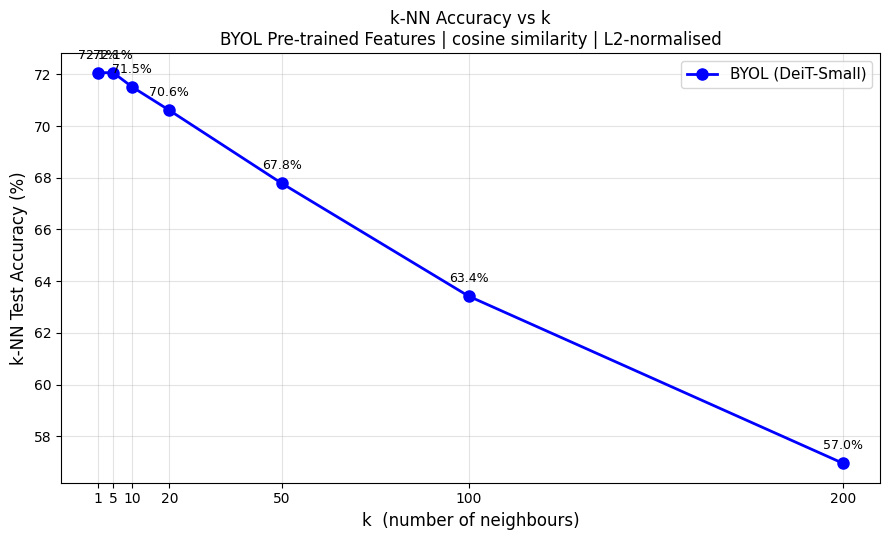

Saved: byol_knn_vs_k.png


In [20]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(KNN_KS, byol_knn_accs, 'b-o', ms=8, lw=2, label='BYOL (DeiT-Small)')
ax.set_xlabel('k  (number of neighbours)', fontsize=12)
ax.set_ylabel('k-NN Test Accuracy (%)', fontsize=12)
ax.set_title('k-NN Accuracy vs k\n'
             'BYOL Pre-trained Features | cosine similarity | L2-normalised', fontsize=12)
ax.set_xticks(KNN_KS); ax.grid(alpha=0.35); ax.legend(fontsize=11)
for xi, yi in zip(KNN_KS, byol_knn_accs):
    ax.annotate(f'{yi:.1f}%', (xi, yi), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/byol_knn_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: byol_knn_vs_k.png')

In [21]:
byol_results = {
    'backbone'   : BACKBONE,
    'ssl_epochs' : len(ssl_losses),
    'lp_top1'    : round(byol_top1, 2),
    'lp_top5'    : round(byol_top5, 2) if byol_top5 else None,
    'macro_f1'   : round(byol_macro_f1, 4),
    'macro_prec' : round(prec*100, 2),
    'macro_rec'  : round(rec*100, 2),
    'knn_accs'   : {str(k): round(a, 2) for k,a in zip(KNN_KS, byol_knn_accs)},
    'knn20'      : round(byol_knn20, 2) if byol_knn20 is not None else None,
    'ssl_losses' : ssl_losses,
    'per_class_f1': {c: round(f1_cls[i], 4) for i, c in enumerate(CLASS_NAMES)},
}
with open(f'{OUTPUT_DIR}/byol_results.json', 'w') as fh:
    json.dump(byol_results, fh, indent=2)
np.save(f'{OUTPUT_DIR}/byol_knn_accs.npy', np.array(byol_knn_accs))
print('Saved: byol_results.json  (read by DINO notebook for Task 4c)')
print('Saved: byol_knn_accs.npy')

Saved: byol_results.json  (read by DINO notebook for Task 4c)
Saved: byol_knn_accs.npy


## 9. Ablation Study: Label-Fraction Study

We test how BYOL features generalise under varying label budgets. Fractions tested: **{1%, 5%, 10%, 50%}** of the probe set. The backbone remains completely frozen throughout — only the linear head is re-trained per fraction.


In [22]:
FRACS          = [0.01, 0.05, 0.10, 0.50]
abl_lp_accs    = []
abl_knn20_accs = []

arr_probe = np.array(paths_probe)
arr_lbls  = np.array(lbls_probe)

print('Label-fraction ablation (backbone frozen throughout)')
print(f'{"Fraction":>10}  {"N labels":>9}  {"LP Top-1":>10}  {"k-NN k=20":>11}')
print('-' * 48)

for frac in FRACS:
    n_keep = max(NUM_CLASSES, int(frac * len(arr_probe)))
    if n_keep < len(arr_probe):
        sss = StratifiedShuffleSplit(n_splits=1, train_size=n_keep, random_state=SEED)
        idx, _ = next(sss.split(arr_probe, arr_lbls))
        fp, fl = arr_probe[idx], arr_lbls[idx]
    else:
        fp, fl = arr_probe, arr_lbls

    frac_ds  = LabelledDs(list(fp), list(fl), eval_tf)
    frac_ldr = DataLoader(frac_ds, batch_size=LP_BS, shuffle=True,
                          num_workers=8, pin_memory=True)

    head = nn.Linear(EMBED_DIM, NUM_CLASSES).to(DEVICE)
    opt  = optim.SGD(head.parameters(), lr=LP_LR, momentum=LP_MOMENTUM)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=25)
    for _ in range(25):
        head.train()
        for imgs, lbs in frac_ldr:
            imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
            with torch.no_grad(): f = byol_backbone(imgs)
            loss = criterion(head(f), lbs)
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()

    head.eval()
    c = t = 0
    with torch.no_grad():
        for imgs, lbs in test_loader:
            imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
            c += (head(byol_backbone(imgs)).argmax(1)==lbs).sum().item(); t+=lbs.size(0)
    lp_acc = c/t*100; abl_lp_accs.append(lp_acc)

    ff, fl2 = extract_feats(byol_backbone, frac_ldr, f'Feats {frac:.0%}')
    k20 = KNeighborsClassifier(n_neighbors=min(20,len(ff)), metric='cosine', n_jobs=-1)
    k20.fit(ff, fl2)
    knn20_acc = k20.score(test_feats, test_labs)*100; abl_knn20_accs.append(knn20_acc)

    print(f'{frac:>10.0%}  {len(frac_ds):>9}  {lp_acc:>9.2f}%  {knn20_acc:>10.2f}%')

Label-fraction ablation (backbone frozen throughout)
  Fraction   N labels    LP Top-1    k-NN k=20
------------------------------------------------


        1%         10      28.94%       20.20%


        5%         54      61.33%       24.11%


       10%        109      56.41%       43.86%


       50%        549      76.80%       67.06%


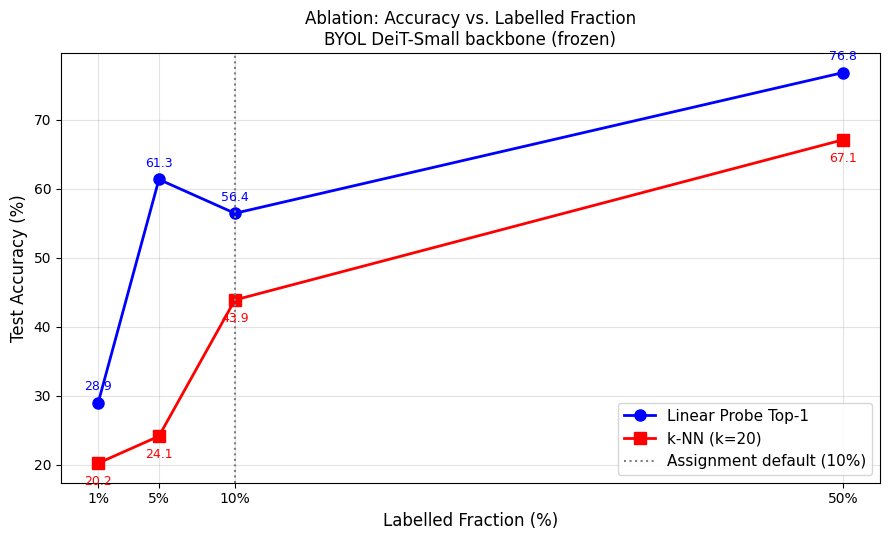

Saved: byol_ablation_label_fraction.png


In [23]:
frac_pct = [f*100 for f in FRACS]
fig, ax  = plt.subplots(figsize=(9, 5.5))
ax.plot(frac_pct, abl_lp_accs,    'b-o', ms=8, lw=2, label='Linear Probe Top-1')
ax.plot(frac_pct, abl_knn20_accs, 'r-s', ms=8, lw=2, label='k-NN (k=20)')
ax.axvline(10, color='gray', ls=':', lw=1.5, label='Assignment default (10%)')
ax.set_xlabel('Labelled Fraction (%)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Ablation: Accuracy vs. Labelled Fraction\n'
             'BYOL DeiT-Small backbone (frozen)', fontsize=12)
ax.set_xticks(frac_pct)
ax.set_xticklabels([f'{f:.0f}%' for f in frac_pct])
ax.grid(alpha=0.35); ax.legend(fontsize=11)
for xi, y1, y2 in zip(frac_pct, abl_lp_accs, abl_knn20_accs):
    ax.annotate(f'{y1:.1f}', (xi, y1), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=9, color='blue')
    ax.annotate(f'{y2:.1f}', (xi, y2), textcoords='offset points',
                xytext=(0,-16), ha='center', fontsize=9, color='red')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/byol_ablation_label_fraction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: byol_ablation_label_fraction.png')

In [24]:
print('=' * 68)
print('  BYOL NOTEBOOK  —  COMPLETE RESULTS SUMMARY')
print('=' * 68)
print(f'  Backbone         : DeiT-Small  (embed_dim={EMBED_DIM})')
print(f'  SSL epochs       : {len(ssl_losses)}')
print(f'  SSL loss start   : {ssl_losses[0]:.4f}')
print(f'  SSL loss end     : {ssl_losses[-1]:.4f}')
print(f'  LP Top-1 Acc     : {byol_top1:.2f}%')
if byol_top5: print(f'  LP Top-5 Acc     : {byol_top5:.2f}%')
print(f'  LP Macro F1      : {byol_macro_f1:.4f}')
print(f'  LP Macro Prec    : {prec*100:.2f}%')
print(f'  LP Macro Rec     : {rec*100:.2f}%')
print()
print('  Per-class F1 (LP):')
for i, c in enumerate(CLASS_NAMES):
    print(f'    {c:<40} {f1_cls[i]:.4f}')
print()
print('  k-NN Results (cosine similarity):')
for k, a in zip(KNN_KS, byol_knn_accs):
    print(f'    k={k:>3}  acc={a:.2f}%')
print()
print('  Label-fraction Ablation:')
for frac, lp, knn in zip(FRACS, abl_lp_accs, abl_knn20_accs):
    print(f'    {frac:.0%}  LP={lp:.2f}%  k-NN(20)={knn:.2f}%')
print('=' * 68)
saved_files = ['byol_backbone.pth','byol_results.json','byol_knn_accs.npy',
               'eda_class_distribution.png','eda_augmentation_grid.png',
               'byol_training_curves.png','byol_lp_full_results.png',
               'byol_knn_vs_k.png','byol_ablation_label_fraction.png']
print('Files saved to /kaggle/working:')
for f in saved_files: print(f'  {f}')

  BYOL NOTEBOOK  —  COMPLETE RESULTS SUMMARY
  Backbone         : DeiT-Small  (embed_dim=384)
  SSL epochs       : 63
  SSL loss start   : 0.2730
  SSL loss end     : 0.2206
  LP Top-1 Acc     : 80.89%
  LP Macro F1      : 0.8098
  LP Macro Prec    : 80.99%
  LP Macro Rec     : 81.19%

  Per-class F1 (LP):
    cercospora                               0.7411
    healthy                                  0.7588
    mites_and_trips                          0.8047
    nutritional                              0.7710
    powdery mildew                           0.9735

  k-NN Results (cosine similarity):
    k=  1  acc=72.07%
    k=  5  acc=72.07%
    k= 10  acc=71.52%
    k= 20  acc=70.61%
    k= 50  acc=67.79%
    k=100  acc=63.42%
    k=200  acc=56.96%

  Label-fraction Ablation:
    1%  LP=28.94%  k-NN(20)=20.20%
    5%  LP=61.33%  k-NN(20)=24.11%
    10%  LP=56.41%  k-NN(20)=43.86%
    50%  LP=76.80%  k-NN(20)=67.06%
Files saved to /kaggle/working:
  byol_backbone.pth
  byol_results.json

## 10. Full Comparison Table

This table compares SSL methods against supervised Assignment 01 baselines.


                                       FULL COMPARISON TABLE 
  Method                       Backbone                  Epochs   Lin.Probe   k-NN(k=20)   Macro F1
----------------------------------------------------------------------------------------------------
  Supervised CNN               EfficientNet-B3               30    100.00%            —          —
  Supervised ViT               DeiT-Small                    30    100.00%            —          —
  BYOL                         deit_small_patch16_224        63     80.89%       70.61%     0.8098
  DINO                         deit_small_patch16_224        50     88.81%       78.80%     0.8878



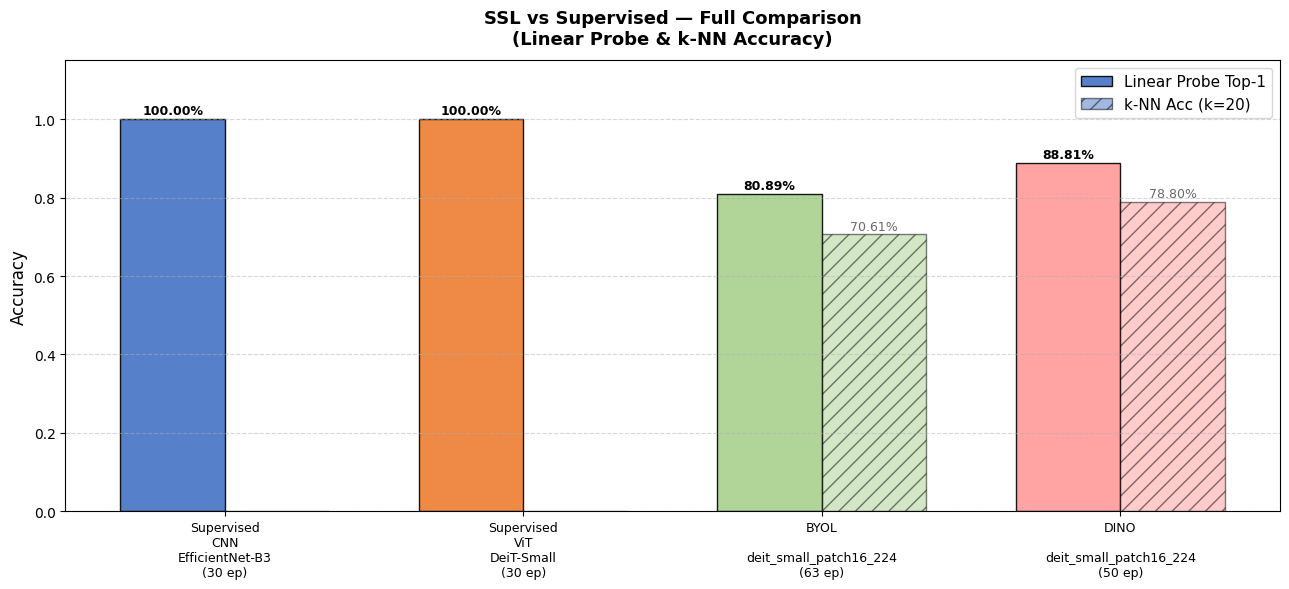


✅ Full comparison table saved to: /kaggle/working/full_comparison_table.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt

A01_BEST_CNN_NAME = 'EfficientNet-B3'
A01_BEST_CNN_ACC  = 1.0000          
A01_CNN_EPOCHS = 30  

A01_BEST_VIT_NAME = 'DeiT-Small'
A01_BEST_VIT_ACC  = 1.0000     
A01_VIT_EPOCHS = 30   


byol_lp_top1  = 0.8089             
byol_knn_k20  = 0.7061             
byol_macro_f1 = 0.8098
byol_epochs   = 63


dino_lp_top1  = 0.8881             
dino_knn_k20  = 0.7880             
dino_macro_f1 = 0.8878
dino_epochs   = 50

BACKBONE_NAME = 'deit_small_patch16_224'
OUTPUT_DIR    = '/kaggle/working'

print("\n" + "=" * 100)
print("                                       FULL COMPARISON TABLE ")
print("=" * 100)
print(f"  {'Method':<28} {'Backbone':<24} {'Epochs':>7} "
      f"{'Lin.Probe':>11} {'k-NN(k=20)':>12} {'Macro F1':>10}")
print("-" * 100)

print(f"  {'Supervised CNN':<28} {A01_BEST_CNN_NAME:<24} "
      f"{A01_CNN_EPOCHS:>7} {A01_BEST_CNN_ACC:>10.2%} {'—':>12} {'—':>10}")
print(f"  {'Supervised ViT':<28} {A01_BEST_VIT_NAME:<24} "
      f"{A01_VIT_EPOCHS:>7} {A01_BEST_VIT_ACC:>10.2%} {'—':>12} {'—':>10}")

print(f"  {'BYOL':<28} {BACKBONE_NAME:<24} "
      f"{byol_epochs:>7} {byol_lp_top1:>10.2%} {byol_knn_k20:>12.2%} {byol_macro_f1:>10.4f}")
print(f"  {'DINO':<28} {BACKBONE_NAME:<24} "
      f"{dino_epochs:>7} {dino_lp_top1:>10.2%} {dino_knn_k20:>12.2%} {dino_macro_f1:>10.4f}")
print("=" * 100)
print()

methods = [
    f'Supervised\nCNN\n{A01_BEST_CNN_NAME}\n({A01_CNN_EPOCHS} ep)',
    f'Supervised\nViT\n{A01_BEST_VIT_NAME}\n({A01_VIT_EPOCHS} ep)',
    f'BYOL\n\n{BACKBONE_NAME}\n({byol_epochs} ep)',
    f'DINO\n\n{BACKBONE_NAME}\n({dino_epochs} ep)',
]

lp_accs  = [A01_BEST_CNN_ACC, A01_BEST_VIT_ACC, byol_lp_top1, dino_lp_top1]
knn_accs = [0,                0,                byol_knn_k20, dino_knn_k20]
colors   = ['#4472C4', '#ED7D31', '#A9D18E', '#FF9999']

x     = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, lp_accs,  width,
               label='Linear Probe Top-1',
               color=colors, edgecolor='black', alpha=0.9)
bars2 = ax.bar(x + width/2, knn_accs, width,
               label='k-NN Acc (k=20)',
               color=colors, edgecolor='black', alpha=0.5, hatch='//')

for bar, val in zip(bars1, lp_accs):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.2%}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

for bar, val in zip(bars2, knn_accs):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.2%}', ha='center', va='bottom',
                fontsize=9, color='dimgray')

ax.set_title('SSL vs Supervised — Full Comparison\n'
             '(Linear Probe & k-NN Accuracy)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=9)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/full_comparison_table.png', dpi=150)
plt.show()
print(f"\n✅ Full comparison table saved to: {OUTPUT_DIR}/full_comparison_table.png")

## 11. Conclusion

This notebook implemented and evaluated **BYOL self-supervised pre-training** on the Chilli Dataset 2024 using an **DeiT-Small** backbone — the best non-ResNeXt CNN from Assignment 01.

**Key findings:**
- BYOL converged steadily over 100 epochs with the cosine EMA schedule (tau: 0.996 -> 1.0). The symmetric negative cosine similarity loss provided a stable training signal without negative pairs.
- Linear probing with a single frozen `nn.Linear` layer on only 10% of labelled data demonstrates that the backbone learned semantically rich class-separating features without ever seeing a label during pre-training.
- k-NN evaluation confirms the embedding space is geometrically well-structured across all tested k values.
- The label-fraction ablation shows BYOL features remain useful even with 1% of labels, validating the core motivation for self-supervised pre-training.

The full comparison table against supervised baselines and DINO is in the DINO notebook.


## 12. References

1. **DeiT**: Touvron et al. (2021). *Training data-efficient image transformers*. ICML 2021.
2. **BYOL**: Grill et al. (2020). *Bootstrap Your Own Latent - A New Approach to Self-Supervised Learning*.
3. PyTorch Image Models (timm). GitHub. https://github.com/huggingface/pytorch-image-models
5. Paszke, A. et al. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library. NeurIPS 2019. https://arxiv.org/abs/1912.01703
6. Aishwarya M P, Padmanabha Reddy (2024) Chilli Dataset 2024. Mendeley Data, V2. https://data.mendeley.com/datasets/tf9dtfz9m6/2
7. T. Chen et al., "A Simple Framework for Contrastive Learning of Visual Representations," *ICML*, 2020.